### **Determinants and Prediction of Global Economic Growth: An Ensemble Model Approach**

**MSc Research Project** | Artificial Intelligence and Data Science  
**Author:** Nadia Ayar Rojas  

---

#### Step 0: Environment Setup and Library Initialisation

This script imports all requisite libraries for data manipulation, modelling, and visualisation, configures system warnings, and initialises random number generators to specific seed values to ensure the entire analysis remains stable and fully reproducible.

In [1]:
# STEP 0: ENVIRONMENT SETUP AND LIBRARY INITIALISATION

# 0.1 Libraries
# Standard Python Libraries
import os
import random
import warnings
from math import sqrt

# Core Data Science Libraries
import numpy as np
import pandas as pd

# Visualisation Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning: Scikit-Learn
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.feature_selection import RFE

# Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Metrics
from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error, 
    r2_score
)

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Explainability & Interpretation
import shap

# 0.2 Reproducibility
# Define the seed value (can be any value)
SEED_VALUE = 42

# Set the seed for Python's internal hashing
# This affects how structures such as dictionaries and sets are ordered
os.environ['PYTHONHASHSEED'] = str(SEED_VALUE)

# Set the seed for Python's random module
# which is used to generate basic random numbers
random.seed(SEED_VALUE)

# Set the seed for NumPy's random number generator
# used in statistical operations, simulations, and synthetic data generation
np.random.seed(SEED_VALUE)

# Sets the seed for TensorFlow's random number generator
# essential for reproducing results in neural networks, weight initialisation, and stochastic operations
tf.random.set_seed(SEED_VALUE)

# Force TensorFlow strict determinism (if supported by hardware)
try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow determinism is enabled")
except AttributeError:
    print("Warning: 'enable_op_determinism' not supported.")

print(f"Random seed set to: {SEED_VALUE}")

# 0.3 Configuration
# Warnings for cleaner output
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Filter TensorFlow logs

print(f"\nStep 0 is complete.")

C:\Users\Nadia Ayar\AppData\Roaming\Python\Python39\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow determinism is enabled
Random seed set to: 42

Step 0 is complete.


#### Step 1: Configuration and Dictionaries

In this step, the following are configured:
1. The name of the files to be loaded
2. The target variable, and the ranking variable for country selection
3. The 60 predictor variables (organised by theme)

In [2]:
# STEP 1: CONFIGURATION AND DICTIONARIES

# 1.1 Files Names
FILES = {
    'data': 'WDICSV.csv',  # Includes the values of all the variables, countries and years    
    'country': 'WDICountry.csv' # Includes the information about the countries
}

# 1.2 Target and Ranking Variables
TARGET_VARIABLE_CODE = 'NY.GDP.PCAP.PP.KD'
TARGET_VARIABLE_NAME = 'GDP per Capita (PPP, Constant 2017)'
RANKING_VARIABLE_CODE = 'NY.GDP.MKTP.KD' # Used for country selection

# 1.3 Predictor Variables (X) (60 Variables)
wdi_variable_candidates = {
    'Poverty_and_Inequality': {
        'SL.UEM.1524.ZS': 'Unemployment, youth total (% of total labor force ages 15-24)',
        'EG.ELC.ACCS.ZS': 'Access to electricity (% of population)',
        'EG.CFT.ACCS.ZS': 'Access to clean fuels and technologies for cooking (% of population)',
        'SN.ITK.DEFC.ZS': 'Prevalence of undernourishment (% of population)',
        'SP.RUR.TOTL.ZS': 'Rural population (% of total population)',
        'SH.XPD.CHEX.GD.ZS': 'Current health expenditure (% of GDP)',
        'SH.STA.BASS.ZS': 'People using at least basic sanitation services (% of population)',
        'SH.H2O.BASW.ZS': 'People using at least basic drinking water services (% of population)',
        'SH.DYN.MORT': 'Mortality rate, under-5 (per 1,000 live births)',
        'SI.POV.NAHC': 'Poverty headcount ratio at national poverty lines (% of population)',
    },
    'People': {
        'SP.POP.GROW': 'Population growth (annual %)',
        'SP.DYN.LE00.IN': 'Life expectancy at birth, total (years)',
        'SE.TER.ENRR': 'School enrollment, tertiary (% gross)',
        'SE.XPD.TOTL.GD.ZS': 'Government expenditure on education, total (% of GDP)',
        'SL.TLF.CACT.ZS': 'Labor force participation rate, total (% of total population ages 15+)',
        'SP.POP.DPND': 'Age dependency ratio (% of working-age population)',
        'SP.URB.GROW': 'Urban population growth (annual %)',
        'SP.DYN.TFRT.IN': 'Fertility rate, total (births per woman)',
        'SE.PRM.ENRR': 'School enrollment, primary (% gross)',
        'SP.ADO.TFRT': 'Adolescent fertility rate (births per 1,000 women ages 15-19)',
    },
    'Environment': {
        'EG.USE.PCAP.KG.OE': 'Energy use (kg of oil equivalent per capita)',
        'EN.GHG.CO2.PC.CE.AR5': 'Carbon dioxide (CO2) emissions excluding LULUCF per capita',
        'EG.FEC.RNEW.ZS': 'Renewable energy consumption (% of total final energy consumption)',
        'AG.LND.ARBL.ZS': 'Arable land (% of land area)',
        'AG.LND.FRST.ZS': 'Forest area (% of land area)',
        'AG.LND.AGRI.ZS': 'Agricultural land (% of land area)',
        'AG.LND.IRIG.AG.ZS': 'Agricultural irrigated land (% of total agricultural land)',
        'NY.GDP.TOTL.RT.ZS': 'Total natural resources rents (% of GDP)',
        'EN.ATM.PM25.MC.M3': 'PM2.5 air pollution, mean annual exposure',
        'ER.H2O.FWTL.ZS': 'Annual freshwater withdrawals, total (% of internal resources)',
    },
    'Economy': {
        'FP.CPI.TOTL.ZG': 'Inflation, consumer prices (annual %)',
        'FR.INR.RINR': 'Real interest rate (%)',
        'NE.GDI.TOTL.ZS': 'Gross capital formation (% of GDP)',
        'NY.GNS.ICTR.ZS': 'Gross savings (% of GDP)',
        'NE.CON.GOVT.ZS': 'General government final consumption expenditure (% of GDP)',
        'SL.UEM.TOTL.ZS': 'Unemployment, total (% of total labor force)',
        'FM.LBL.BMNY.GD.ZS': 'Broad money (% of GDP)',
        'FS.AST.PRVT.GD.ZS': 'Domestic credit to private sector (% of GDP)',
        'NV.AGR.TOTL.ZS': 'Agriculture, forestry, and fishing, value added (% of GDP)',
        'NV.IND.TOTL.ZS': 'Industry (including construction), value added (% of GDP)',
    },
    'States_and_Markets': {
        'IC.BUS.NDNS.ZS': 'New business density (new registrations per 1,000 people)',
        'GC.TAX.TOTL.GD.ZS': 'Tax revenue (% of GDP)',
        'MS.MIL.XPND.GD.ZS': 'Military expenditure (% of GDP)',
        'FR.INR.LNDP': 'Interest rate spread (lending rate minus deposit rate, %)',
        'IT.CEL.SETS.P2': 'Mobile cellular subscriptions (per 100 people)',
        'IT.NET.USER.ZS': 'Individuals using the Internet (% of population)',
        'CC.EST': 'Control of Corruption: Estimate',
        'PV.EST': 'Political Stability and Absence of Violence/Terrorism: Estimate',
        'GE.EST': 'Government Effectiveness: Estimate',
        'CM.MKT.LCAP.GD.ZS': 'Market capitalization of listed domestic companies (% of GDP)',
    },
    'Global_Links': {
        'NE.TRD.GNFS.ZS': 'Trade (% of GDP)',
        'NE.EXP.GNFS.ZS': 'Exports of goods and services (% of GDP)',
        'NE.IMP.GNFS.ZS': 'Imports of goods and services (% of GDP)',
        'BX.KLT.DINV.WD.GD.ZS': 'Foreign direct investment, net inflows (% of GDP)',
        'BX.TRF.PWKR.DT.GD.ZS': 'Personal remittances, received (% of GDP)',
        'DT.ODA.ODAT.GN.ZS': 'Net official development assistance received (% of GNI)',
        'DT.DOD.DECT.GN.ZS': 'External debt stocks (% of GNI)',
        'TM.TAX.MRCH.SM.AR.ZS': 'Tariff rate, applied, simple mean, all products (%)',
        'ST.INT.ARVL': 'International tourism, number of arrivals',
        'TG.VAL.TOTL.GD.ZS': 'Merchandise trade (% of GDP)',
    }
}

# 1.4 Mapping Helpers
# Create a direct mapping from WDI Code to Readable Name for future DataFrame formatting

# Empty dictionary and list to store information
name_map = {}
all_x_codes = []

# Add the information to the dictionary and list
for theme, variables in wdi_variable_candidates.items():
    for code, name in variables.items():
        name_map[code] = name
        all_x_codes.append(code)

# Add Target and Ranking variables to the map
name_map[TARGET_VARIABLE_CODE] = TARGET_VARIABLE_NAME
name_map[RANKING_VARIABLE_CODE] = 'Total GDP (Ranking)'

# Create a master list of all codes needed to be extracted from the raw CSV
# This includes predictors (X), the Target (Y), and the Ranking variable
all_needed_codes = all_x_codes + [TARGET_VARIABLE_CODE, RANKING_VARIABLE_CODE]

print(f"Total predictor variables defined (X): {len(all_x_codes)}")
print(f"\nStep 1 is complete.")

Total predictor variables defined (X): 60

Step 1 is complete.


#### Step 2: Loading and Initial Pre-processing

This step loads the CSV files, restructures the data from a 'wide' to a 'long' format using the <code>melt</code> function, and creates the initial DataFrame by applying two filters: 1) a filter to retain only countries (and not groups), and 2) a filter to retain only the defined variables.

In [3]:
# STEP 2: LOADING AND INITIAL PRE-PROCESSING

# 2.1 Load Raw Data
df_raw = pd.read_csv(FILES['data'])
df_country = pd.read_csv(FILES['country'])

# 2.2 Transform Wide to Long (Melt)
# World Bank data comes with years as columns (e.g., 1960, 1961...)
# Melt this into a 'Year' column to have the years in rows
year_cols = [col for col in df_raw.columns if col.isdigit()]
df_melted = df_raw.melt(
    id_vars=['Country Code', 'Indicator Code'], 
    value_vars=year_cols, 
    var_name='Year', 
    value_name='Value'
)
# Convert the years to integers 
df_melted['Year'] = df_melted['Year'].astype(int)

# 2.3 Merge Metadata (To get Country Names and Regions)
# 'Table Name' as Country Name
country_meta = df_country[['Country Code', 'Table Name', 'Income Group', 'Region']].drop_duplicates()
df_enriched = df_melted.merge(country_meta, on='Country Code', how='left')

# 2.4 Filter Aggregates
# Remove groups of countries like "World", "Arab World", etc., which do not have a 'Region'
df_enriched = df_enriched.dropna(subset=['Region', 'Income Group'])

# 2.5 Translate Codes to Readable Names
# using the 'name_map' created in Step 1
df_enriched['Variable Name'] = df_enriched['Indicator Code'].map(name_map)
# Rename 'Table Name' columna by 'Country Name'
df_enriched.rename(columns={'Table Name': 'Country Name'}, inplace=True)

# 2.6 Filter to Defined Variables
df_enriched = df_enriched[df_enriched['Indicator Code'].isin(all_needed_codes)].copy()

# Calculate the dimensions
number_of_countries_in_df_enriched = len(df_enriched['Country Name'].unique())
number_of_variables_in_df_enriched = len(df_enriched['Indicator Code'].unique())
number_of_years_in_df_enriched = len(df_enriched['Year'].unique())

print(f"df_enriched dataset dimensions: {df_enriched.shape}")
print(f"{number_of_countries_in_df_enriched} countries * {number_of_variables_in_df_enriched} variables * {number_of_years_in_df_enriched} years = {number_of_countries_in_df_enriched * number_of_variables_in_df_enriched * number_of_years_in_df_enriched}")
print(f"\nStep 2 is complete.")
df_enriched.head(3)

df_enriched dataset dimensions: (866450, 8)
215 countries * 62 variables * 65 years = 866450

Step 2 is complete.


,Country Code,Indicator Code,Year,Value,Country Name,Income Group,Region,Variable Name
74284,AFG,EG.CFT.ACCS.ZS,1960,NaN,Afghanistan,Low income,Middle East & North Africa,Access to clean fuels and technologies for coo...
74287,AFG,EG.ELC.ACCS.ZS,1960,NaN,Afghanistan,Low income,Middle East & North Africa,Access to electricity (% of population)
74334,AFG,SP.ADO.TFRT,1960,140.598,Afghanistan,Low income,Middle East & North Africa,"Adolescent fertility rate (births per 1,000 wo..."


#### Step 3: Data Availability Analysis

This step generates a bar chart to visually justify the choice of time period.

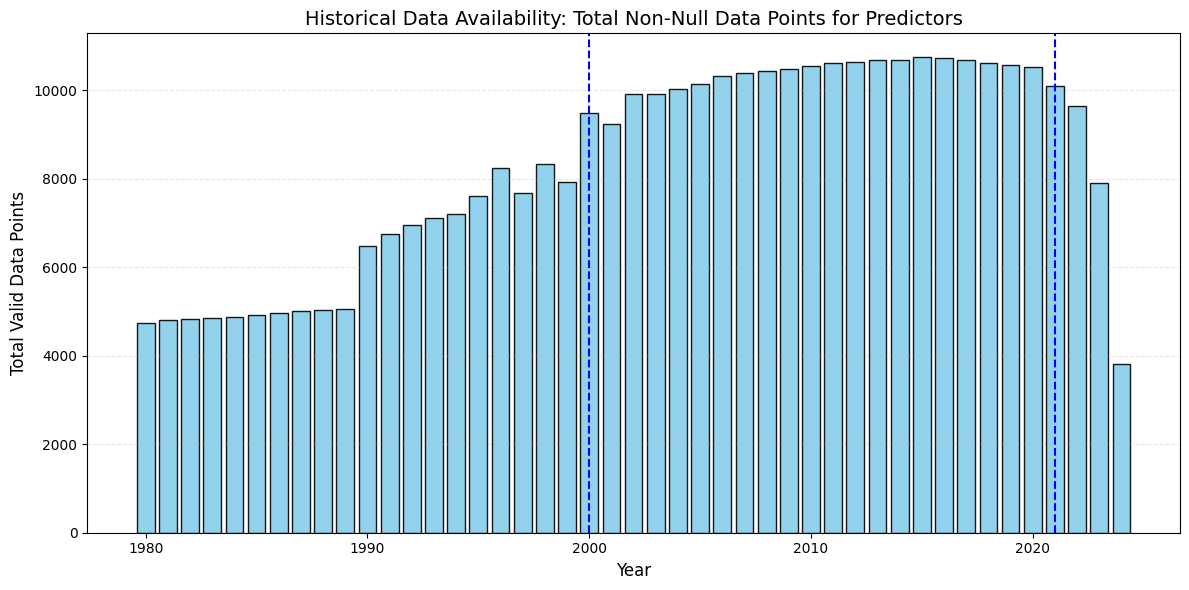

Step 3 is complete.


In [4]:
# STEP 3: DATA AVAILABILITY ANALYSIS (HISTORICAL)

# 3.1 Filter Data for Plotting
# Focus only on the 60 predictor variables (X)
# View from 1980 onwards to show the lack of data in early decades
plot_data = df_enriched[
    (df_enriched['Indicator Code'].isin(all_x_codes)) & 
    (df_enriched['Year'] >= 1980)
].copy()

# 3.2 Calculate Total Valid Data Points per Year
# Count non-null values across all countries and all predictor variables
availability_counts = plot_data.dropna(subset=['Value']).groupby('Year')['Value'].count()

# 3.3 Plot
plt.figure(figsize=(12, 6))

# Plot the bars
plt.bar(availability_counts.index, availability_counts.values, color='skyblue', edgecolor='black', alpha=0.9)

# Add formatting
plt.title('Historical Data Availability: Total Non-Null Data Points for Predictors', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Valid Data Points', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add visual markers for the intended analysis period (2000-2021)
plt.axvline(x=2000, color='blue', linestyle='--', linewidth=1.5)
plt.axvline(x=2021, color='blue', linestyle='--', linewidth=1.5)

# 3.4 Save and Show
plt.tight_layout()
plt.savefig('period_justification.png', dpi=300)
plt.show()

print(f"Step 3 is complete.")

#### Step 4: Country Selection and Period Filter

This step applies the time filter based on the chart from Step 3 (restricting the data to 2000-2021) and then executes the two-stage country selection algorithm:
1) Only countries with data availability greater than 75% are included (quality rule), and
2) The 15 most relevant countries in terms of GDP by income level are selected (relevance rule).

In [5]:
# STEP 4. COUNTRY SELECTION AND PERIOD FILTER

# 4.1 Define Analysis Period and Filter Data
START_YEAR = 2000
END_YEAR = 2021

df_period = df_enriched[
    (df_enriched['Year'] >= START_YEAR) & 
    (df_enriched['Year'] <= END_YEAR)
].copy()

# 4.2 Stage 1: Data Quality Filter (>75% Availability)
# Filter for predictor (X) data only
x_data_period = df_period[df_period['Indicator Code'].isin(all_x_codes)]

# Pivot to count valid data points per country
# Index: Country Code
# Columns: Indicator Code
# Values: Count of non-null years
data_matrix = x_data_period.pivot_table(
    index='Country Code', 
    columns='Indicator Code', 
    values='Value', 
    aggfunc='count'
).fillna(0)

# Calculate availability score
# Theoretical max points = 60 variables * 22 years (2000-2021) = 1320 points
theoretical_max_points = len(all_x_codes) * (END_YEAR - START_YEAR + 1)
data_matrix['total_points'] = data_matrix.sum(axis=1)
data_matrix['availability_pct'] = (data_matrix['total_points'] / theoretical_max_points) * 100

# Merge metadata to filter by availability and income group
selection_df = data_matrix[['availability_pct']].merge(country_meta, on='Country Code', how='left')

# Apply the 75% filter
candidates_stage_1 = selection_df[selection_df['availability_pct'] >= 75.0].copy()

# 4.3 Stage 2: Economic Relevance Filter (Top 15 by Last Year GDP)
# From the quality list, pick the 15 largest economies from each income group

# Get GDP from the last year (END_YEAR)
gdp_last_year_data = df_period[
    (df_period['Indicator Code'] == RANKING_VARIABLE_CODE) &
    (df_period['Year'] == END_YEAR)
]

# Select and rename the ranking column
gdp_ranking_data = gdp_last_year_data[['Country Code', 'Value']].rename(columns={'Value': f'GDP_{END_YEAR}'})

# Merge GDP data into candidates
candidates_stage_2 = candidates_stage_1.merge(gdp_ranking_data, on='Country Code', how='left')

# Handle potential NaNs in GDP for 2021 (if a country has no data for that specific year)
# We fill with 0 so nlargest() doesn't fail, but they will be ranked last.
#candidates_stage_2[f'GDP_{END_YEAR}'] = candidates_stage_2[f'GDP_{END_YEAR}'].fillna(0)

# Selection List
final_country_codes = []
income_groups = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']

# Table 
TABLE_WIDTH = 57
print("=" * TABLE_WIDTH)
print(f"{'COUNTRY SELECTION REPORT':^{TABLE_WIDTH}}")
print("=" * TABLE_WIDTH)

for group in income_groups:
    # Title
    print(f"\n{group.upper():^{TABLE_WIDTH}}")
    print("-" * TABLE_WIDTH)
    # Header
    print(f"{'Country Name':<25} | {'Data %':<7} | {'GDP 2021 (USD)':>15}")
    print("-" * TABLE_WIDTH)

    # Filter by group
    group_df = candidates_stage_2[candidates_stage_2['Income Group'] == group]
    # Pick Top 15 by LAST YEAR's GDP
    top_15 = group_df.nlargest(15, f'GDP_{END_YEAR}')
    # Store and Print
    final_country_codes.extend(top_15['Country Code'].tolist())
    for _, row in top_15.iterrows():
        gdp_value = row[f'GDP_{END_YEAR}']
        gdp_formatted = f"{(gdp_value / 1_000_000_000):,.2f}B"
            
        print(f"{row['Table Name']:<25} | {row['availability_pct']:.1f}%   | {gdp_formatted:>15}")
    print("-" * TABLE_WIDTH)

print(f"Total countries selected for analysis: {len(final_country_codes)}")
print(f"\nStep 4 is complete.")

                COUNTRY SELECTION REPORT                 

                       HIGH INCOME                       
---------------------------------------------------------
Country Name              | Data %  |  GDP 2021 (USD)
---------------------------------------------------------
United States             | 86.6%   |      20,917.85B
Japan                     | 89.2%   |       4,492.01B
Germany                   | 86.3%   |       3,652.21B
United Kingdom            | 90.3%   |       3,074.76B
France                    | 86.1%   |       2,580.12B
Italy                     | 90.6%   |       1,908.09B
Canada                    | 88.3%   |       1,707.00B
Korea, Rep.               | 90.8%   |       1,696.54B
Australia                 | 90.8%   |       1,522.54B
Russian Federation        | 93.0%   |       1,506.23B
Spain                     | 90.1%   |       1,267.00B
Netherlands               | 89.0%   |         872.81B
Switzerland               | 91.7%   |         771.76B
Saudi Arabi

#### Step 5: Final Dataset Construction & Target Variable Engineering

This step builds the final dataset structure. It filters the long-format data to keep only the 60 selected countries, then pivots it into a wide-format (matrix) where rows are Country-Year and columns are your 60 predictor variables. Finally, it calculates the <code>Target_Growth</code> variable applying log difference.

The target variable has 0 null values.
df_final dataset dimensions: (1320, 66)
60 countries * 22 years = 1320


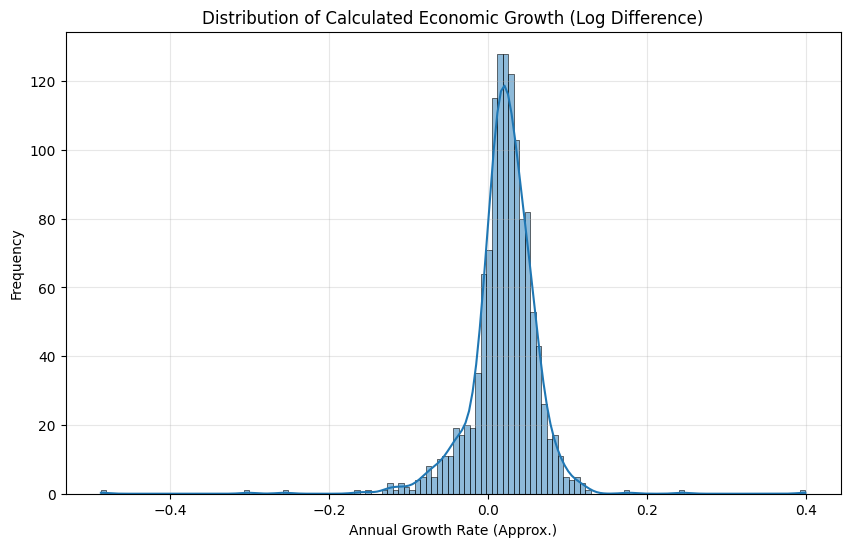


Step 5 is complete.


Variable Name,Country Name,Country Code,Year,Access to clean fuels and technologies for cooking (% of population),Access to electricity (% of population),"Adolescent fertility rate (births per 1,000 women ages 15-19)",Age dependency ratio (% of working-age population),Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",...,"School enrollment, tertiary (% gross)","Tariff rate, applied, simple mean, all products (%)",Tax revenue (% of GDP),Total natural resources rents (% of GDP),Trade (% of GDP),"Unemployment, total (% of total labor force)","Unemployment, youth total (% of total labor force ages 15-24)",Urban population growth (annual %),Log_GDP,Target_Growth
22,Angola,AGO,2000,40.90,24.2,147.693,93.395055,NaN,35.712681,5.664690,...,NaN,NaN,28.703382,59.142510,NaN,16.682,39.083,5.716831,8.700013,NaN
23,Angola,AGO,2001,41.35,20.0,147.253,93.142606,NaN,35.626053,8.156377,...,NaN,NaN,29.246676,44.219477,NaN,16.700,39.051,5.695936,8.707675,0.007662
24,Angola,AGO,2002,41.50,26.3,150.196,92.868988,NaN,35.644501,5.839550,...,0.78364,8.21,15.532812,32.883716,105.301743,16.488,38.542,5.696103,8.801692,0.094017


In [6]:
# STEP 5. FINAL DATASET CONSTRUCTION AND TARGET ENGINEERING

# 5.1 Filter Data for Selected Countries
# Use the list of 60 codes generated in Step 4: final_country_codes
df_final_long = df_period[df_period['Country Code'].isin(final_country_codes)].copy()

# 5.2 Pivot Table (Long to Wide)
# Move variables from rows to columns
# Index: Country identifiers and Year
# Columns: Human-readable Variable Names
df_final = df_final_long.pivot_table(
    index=['Country Name', 'Country Code', 'Year'], 
    columns='Variable Name', 
    values='Value'
).reset_index()

# 5.3 Remove Ranking Variable
# It was used only for country selection
ranking_var_name = name_map[RANKING_VARIABLE_CODE]
if ranking_var_name in df_final.columns:
    df_final = df_final.drop(columns=[ranking_var_name], inplace=False)

# 5.4 Validate No Missing Data in the Target Variable
target_col_name = TARGET_VARIABLE_NAME
print(f"The target variable has {len(df_final[df_final[target_col_name].isna()])} null values.")

# 5.5 Calculate Target Variable (Log Difference)
# Sort by Country and Year to ensure the difference is chronological
df_final.sort_values(by=['Country Code', 'Year'], inplace=True)

# Apply the Log-Difference Transformation
# Formula: Growth_it = ln(GDP_pc_it) - ln(GDP_pc_i,t-1)
# Group by 'Country Code' so the calculation doesn't bleed between different countries
df_final['Log_GDP'] = np.log(df_final[target_col_name])
df_final['Target_Growth'] = df_final.groupby('Country Code')['Log_GDP'].diff()

# Calculate the Dimensions
number_of_countries_in_df_final = len(df_final['Country Name'].unique())
number_of_years_in_df_final = len(df_final['Year'].unique())

print(f"df_final dataset dimensions: {df_final.shape}")
print(f"{number_of_countries_in_df_final} countries * {number_of_years_in_df_final} years = {number_of_countries_in_df_final * number_of_years_in_df_final}")

# 5.6 Visual Sanity Check
# Plot the growth distribution (Bell Curve)
plt.figure(figsize=(10, 6))
sns.histplot(df_final['Target_Growth'].dropna(), kde=True)
plt.title('Distribution of Calculated Economic Growth (Log Difference)')
plt.xlabel('Annual Growth Rate (Approx.)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.savefig('log_diff_distribution.png', dpi=300)
plt.show()

print(f"\nStep 5 is complete.")
df_final.head(3)

#### Step 6: Hybrid Data Imputation (Linear + KNN)

This step is for filling the missing values using a two-phase hybrid strategy:
1) **Linear Interpolation**: Fills gaps within a country's own timeline.
2) **KNN Imputation**: Fills any remaining gaps (usually at the start/end of the data) by looking at mathematically similar countries.

In [7]:
# STEP 6. HYBRID DATA IMPUTATION (LINEAR + KNN)

# 6.1 Identify Predictor Columns (X)
# Ensure the imputation for only the 60 explanatory variables
# Use the 'name_map' to get the readable names from 'all_x_codes'
predictor_cols = [name_map[code] for code in all_x_codes if code in name_map and name_map[code] in df_final.columns]
print(f"Predictor variables to be imputed: {len(predictor_cols)}")
initial_nans = df_final[predictor_cols].isna().sum().sum()
print(f"Initial missing values in X: {initial_nans}")

# 6.2 Phase 1: Linear Interpolation (Intra-Country)
# Group by ‘Country code’ to ensure that data is not mixed between nations
# 'limit_direction=both' helps fill gaps at the very start or end
df_final[predictor_cols] = df_final.groupby('Country Code')[predictor_cols].transform(
    lambda group: group.interpolate(method='linear', limit_direction='both')
)

nans_after_linear = df_final[predictor_cols].isna().sum().sum()
print(f"Missing values remaining after Linear phase: {nans_after_linear}")

# 6.3 Phase 2: KNN Imputation
if nans_after_linear > 0:
    # Use k=10 neighbours as the standard robust value, weighted by distance
    imputer = KNNImputer(n_neighbors=10, weights='distance')

    # Create a subset for imputation
    # KNN requires numeric data (predictor columns are numeric)
    data_for_knn = df_final[predictor_cols].copy()
    # Fit and Transform
    data_imputed_array = imputer.fit_transform(data_for_knn)
    
    # Assign back to the main DataFrame
    df_final[predictor_cols] = pd.DataFrame(
        data_imputed_array, 
        index=df_final.index, 
        columns=predictor_cols
    )
else:
    print("Phase 2 skipped (No missing values left).")

# 6.4 Final Integrity Check
final_nans = df_final[predictor_cols].isna().sum().sum()
print(f"Final check - Total missing values in X: {final_nans}")

Predictor variables to be imputed: 60
Initial missing values in X: 8194
Missing values remaining after Linear phase: 3212
Final check - Total missing values in X: 0


Next script validates the robustness of the k=10 imputation by demonstrating that the data structure can be reconstructed with high precision.

In [8]:
# 6.5 IMPUTATION QUALITY TEST (MASKING SIMULATION)
# This test validates the R² of the k=10 imputation

# 1. Setup Ground Truth
# Use the imputed dataframe as our baseline truth
df_test = df_final[predictor_cols].copy()

# 2. Create Mask (Artificially hide 5% of data)
np.random.seed(SEED_VALUE) # Use the global seed
mask = np.random.rand(*df_test.shape) < 0.05 # 5% of cells are True (hidden)

# Store the actual values to compare later
true_values = df_test.values[mask]

# Create the corrupted dataset
df_corrupted = df_test.copy()
df_corrupted.values[mask] = np.nan # Introduce artificial missingness

print(f"Masking Simulation: Hidden {len(true_values)} data points (5%) for validation.")

# 3. Run KNN Imputation (k=10) on Corrupted Data
imputer_test = KNNImputer(n_neighbors=10, weights='distance')
data_imputed_test = imputer_test.fit_transform(df_corrupted)

# Extract the values guessed by the algorithm
guessed_values = data_imputed_test[mask]

# 4. Calculate Performance Metrics
mse = mean_squared_error(true_values, guessed_values)
rmse = sqrt(mse)
global_std = np.std(true_values)
nrmse = rmse / global_std
r2 = r2_score(true_values, guessed_values)

print(f"\n> KNN Imputation Performance")
print(f"Global NRMSE: {nrmse:.4f} (Lower is better; <0.5 is acceptable)")
print(f"R² Score: {r2:.4f} (Closer to 1.0 is better)")
print(f"RESULT: High R² {r2:.4f} and low NRMSE {nrmse:.4f} confirm the k=10 imputation strategy is robust.")

print(f"\nStep 6 is complete.")

Masking Simulation: Hidden 3917 data points (5%) for validation.

> KNN Imputation Performance
Global NRMSE: 0.3001 (Lower is better; <0.5 is acceptable)
R² Score: 0.9099 (Closer to 1.0 is better)
RESULT: High R² 0.9099 and low NRMSE 0.3001 confirm the k=10 imputation strategy is robust.

Step 6 is complete.


#### Step 7: Temporal Alignment (Lagging Variables t-1)

This step applies the crucial 1-period Lag ($t-1$) to all predictor variables.
<br>This ensures the model uses information from last year to predict growth in the current year, preventing reverse causality.

In [9]:
# STEP 7. TEMPORAL ALIGNMENT (LAGGING VARIABLES t-1)

# 7.1 Define the Shift
# Assume that Growth in year T is caused by conditions in year T-1
# Group by 'Country Code' to prevent data from one country "leaking" into the next
# Apply shift ONLY to predictor columns (X), Target (Y) and Identifiers remain in the current time T
df_final[predictor_cols] = df_final.groupby('Country Code')[predictor_cols].shift(1)

# 7.2 Remove Empty Rows (Year 2000)
# After shifting, the first year (2000) for every country now has NaN 
# for all X variables, as there is no 1999 data
# Drop any rows where the Target_Growth itself is NaN (from Step 5).
rows_before = len(df_final)
df_final = df_final.dropna(subset=predictor_cols + ['Target_Growth'])
rows_dropped = rows_before - len(df_final)

# Calculate the Dimensions
number_of_countries_in_lagged_df_final = len(df_final['Country Name'].unique())
number_of_years_in_lagged_df_final = len(df_final['Year'].unique())

print(f"Lagged df_final dataset dimensions: {df_final.shape}")
print(f"{number_of_countries_in_lagged_df_final} countries * {number_of_years_in_lagged_df_final} years = {number_of_countries_in_lagged_df_final * number_of_years_in_lagged_df_final}")
print(f"Time range: {df_final['Year'].min()} - {df_final['Year'].max()}")
print(f"Total predictors: {len(predictor_cols)}")

print(f"\nStep 7 is complete.")
df_final.head(3)

Lagged df_final dataset dimensions: (1260, 66)
60 countries * 21 years = 1260
Time range: 2001 - 2021
Total predictors: 60

Step 7 is complete.


Variable Name,Country Name,Country Code,Year,Access to clean fuels and technologies for cooking (% of population),Access to electricity (% of population),"Adolescent fertility rate (births per 1,000 women ages 15-19)",Age dependency ratio (% of working-age population),Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",...,"School enrollment, tertiary (% gross)","Tariff rate, applied, simple mean, all products (%)",Tax revenue (% of GDP),Total natural resources rents (% of GDP),Trade (% of GDP),"Unemployment, total (% of total labor force)","Unemployment, youth total (% of total labor force ages 15-24)",Urban population growth (annual %),Log_GDP,Target_Growth
23,Angola,AGO,2001,40.90,24.2,147.693,93.395055,0.300866,35.712681,5.664690,...,0.78364,8.21,28.703382,59.142510,105.301743,16.682,39.083,5.716831,8.707675,0.007662
24,Angola,AGO,2002,41.35,20.0,147.253,93.142606,0.210521,35.626053,8.156377,...,0.78364,8.21,29.246676,44.219477,105.301743,16.700,39.051,5.695936,8.801692,0.094017
25,Angola,AGO,2003,41.50,26.3,150.196,92.868988,3.945583,35.644501,5.839550,...,0.78364,8.21,15.532812,32.883716,105.301743,16.488,38.542,5.696103,8.796220,-0.005472


#### Step 8: Train-Test Split (Chronological)

This step splits your master dataset into two parts: a Training Set (for the model to learn from) and a Testing Set (to evaluate its performance on unseen data), using a chronological split to respect the time-series nature of the data.

In [10]:
# STEP 8. TRAIN-TEST SPLIT (CHRONOLOGICAL)

# 8.1 Define Temporal Boundaries
# Training Phase: Learning the economic relationships (2001-2017)
# Testing Phase: Evaluating predictive performance on unseen future (2018-2021)
TRAIN_END_YEAR = 2017
TEST_START_YEAR = 2018

# 8.2 Create Subsets
train_df = df_final[df_final['Year'] <= TRAIN_END_YEAR].copy()
test_df = df_final[df_final['Year'] >= TEST_START_YEAR].copy()

# 8.3 Separate Features (X) and Target (Y)
# Use 'predictor_cols' (defined in Step 6) to select the 60 predictors.

# Training Set
X_train = train_df[predictor_cols]
y_train = train_df['Target_Growth']
# Testing Set
X_test = test_df[predictor_cols]
y_test = test_df['Target_Growth']

# Calculate the Dimensions
print(f"Training Set (X_train): {X_train.shape} observations")
print(f"Training Target (y_train): {y_train.shape} observations")
number_of_countries_in_train_df = len(train_df['Country Name'].unique())
number_of_years_in_train_df = len(train_df['Year'].unique())
print(f"{number_of_countries_in_train_df} countries * {number_of_years_in_train_df} years = {number_of_countries_in_train_df * number_of_years_in_train_df}")

print(f"\nTesting Set (X_test):   {X_test.shape} observations")
print(f"Testing Target (y_test):   {y_test.shape} observations")
number_of_countries_in_test_df = len(test_df['Country Name'].unique())
number_of_years_in_test_df = len(test_df['Year'].unique())
print(f"{number_of_countries_in_test_df} countries * {number_of_years_in_test_df} years = {number_of_countries_in_test_df * number_of_years_in_test_df}")

# Verify no data leakage (Years should not overlap)
train_years = train_df['Year'].unique()
test_years = test_df['Year'].unique()

if set(train_years).isdisjoint(set(test_years)):
    print("\n> No data leakage.")
else:
    print("\n> Overlap between Train and Test years!")

print(f"\nStep 8 is complete.")

Training Set (X_train): (1020, 60) observations
Training Target (y_train): (1020,) observations
60 countries * 17 years = 1020

Testing Set (X_test):   (240, 60) observations
Testing Target (y_test):   (240,) observations
60 countries * 4 years = 240

> No data leakage.

Step 8 is complete.


#### Step 9: Feature Standardisation (Scaling)

This step is essential for models like Lasso and Neural Networks. It rescales all the predictor variables so they have a mean of 0 and a standard deviation of 1, ensuring that no single variable unfairly dominates the model just because its units are large.

In [11]:
# STEP 9. FEATURE STANDARDISATION (Z-SCORE SCALING)

# 9.1 Initialise Scaler
scaler = StandardScaler()

# 9.2 Fit on Training Data ONLY
# The scaler learns the Mean and Standard Deviation from the 2001-2017 data
# Use .fit() - this does not transform the data yet, just learns the parameters
scaler.fit(X_train)

# 9.3 Transform both Training and Testing Data
# Apply the rules learned from X_train to both sets
# This prevents 'data leakage' from the test set
X_train_scaled_array = scaler.transform(X_train)
X_test_scaled_array = scaler.transform(X_test)

# 9.4 Convert back to DataFrames
# Scaling returns numpy arrays.
# Reconstruct the DataFrames to keep the column names
X_train_scaled = pd.DataFrame(X_train_scaled_array, index=X_train.index, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled_array, index=X_test.index, columns=X_test.columns)

# 9.5 Verification
print(f"Train Set Shape: {X_train_scaled.shape}")
print(f"Test Set Shape:  {X_test_scaled.shape}")

# Check statistics of a sample variable
sample_col = X_train_scaled.columns[0]
mean_val = X_train_scaled[sample_col].mean()
std_val = X_train_scaled[sample_col].std()

print(f"\n> Scaling Verification (Training set)")
print(f"Variable Checked: {sample_col}")
print(f"Original Mean:    {X_train[sample_col].mean():.4f}")
print(f"Scaled Mean:      {mean_val:.4f} (Should be ~0.0)")
print(f"Scaled Std Dev:   {std_val:.4f} (Should be ~1.0)")

print(f"\nStep 9 is complete.")

Train Set Shape: (1020, 60)
Test Set Shape:  (240, 60)

> Scaling Verification (Training set)
Variable Checked: Unemployment, youth total (% of total labor force ages 15-24)
Original Mean:    14.2891
Scaled Mean:      0.0000 (Should be ~0.0)
Scaled Std Dev:   1.0005 (Should be ~1.0)

Step 9 is complete.


#### Step 10: Feature Selection (RFE)

This step uses **Recursive Feature Elimination** (RFE) to select the Top 20 most impactful predictors.
<br>This method will train a simple model on all 60 variables, eliminate the weakest one, retrain on 59, and repeat this process until only the 20 strongest predictors remain.

In [12]:
# STEP 10. FEATURE SELECTION (RECURSIVE FEATURE ELIMINATION)

# 10.1 Initialise the Models
# Use a simple Linear Regression as the judge for RFE
# Fast and effective at finding the variables with the strongest linear signal
estimator = LinearRegression()

# Initialise RFE and tell it to select exactly 20 features
# RFE will repeatedly train the estimator and discard the weakest feature
rfe_selector = RFE(
    estimator=estimator, 
    n_features_to_select=20, # Chosen number of variables
    step=1 # Remove 1 feature at a time
)

# 10.2 Fit RFE on Training Data
rfe_selector.fit(X_train_scaled, y_train)

# 10.3 Extract Selected Features
# Get the boolean mask of which features were kept (True) or dropped (False)
selected_mask = rfe_selector.support_

# Get the names of the 20 surviving features
selected_cols = X_train_scaled.columns[selected_mask].tolist()

# Results
print(f"Total variables fed into model: {len(X_train_scaled.columns)}")
print(f"Variables selected by RFE:      {len(selected_cols)}")

print(f"\nThe 20 Selected Predictors:")
# Print the list of selected variable names
for i, var in enumerate(selected_cols, 1):
    print(f"   {i:>2}. {var}")

# 10.4 Filter Datasets for Modelling
# Create new and smaller DataFrames that only contain these 20 selected columns
# These will be the inputs for all models
X_train_model = X_train_scaled[selected_cols]
X_test_model = X_test_scaled[selected_cols]

print(f"\nNew X_train shape: {X_train_model.shape}")
print(f"New X_test shape:  {X_test_model.shape}")
print(f"\nStep 10 is complete.")

Total variables fed into model: 60
Variables selected by RFE:      20

The 20 Selected Predictors:
    1. Access to electricity (% of population)
    2. Access to clean fuels and technologies for cooking (% of population)
    3. Prevalence of undernourishment (% of population)
    4. People using at least basic sanitation services (% of population)
    5. People using at least basic drinking water services (% of population)
    6. Poverty headcount ratio at national poverty lines (% of population)
    7. Life expectancy at birth, total (years)
    8. Labor force participation rate, total (% of total population ages 15+)
    9. Urban population growth (annual %)
   10. Fertility rate, total (births per woman)
   11. Energy use (kg of oil equivalent per capita)
   12. Carbon dioxide (CO2) emissions excluding LULUCF per capita
   13. PM2.5 air pollution, mean annual exposure
   14. Gross savings (% of GDP)
   15. Domestic credit to private sector (% of GDP)
   16. Agriculture, forestry, a

#### Step 11: Comparative Modelling and Ensembles

This step involves evaluating a diverse set of predictive models to compare their performance and robustness. The models include:
- Ridge Regression (baseline)
- Support Vector Regression (SVR)
- Random Forest
- Long Short-Term Memory (LSTM)
- Hybrid Model: integrating LSTM and Random Forest
  
The models undergo hyperparameter tuning using cross-validation techniques tailored to time series data, ensuring fair and optimised comparisons. To mitigate overfitting, regularisation, dropout, and other model-specific safeguards are applied. Performance is assessed using standard regression metrics, and visualisations are generated to support interpretability.


> Model: Ridge Regression
Best Parameters: {'alpha': 200, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': 42, 'solver': 'auto', 'tol': 0.0001}
RMSE: 0.0464 | MAE: 0.0328 | R²: -0.0821


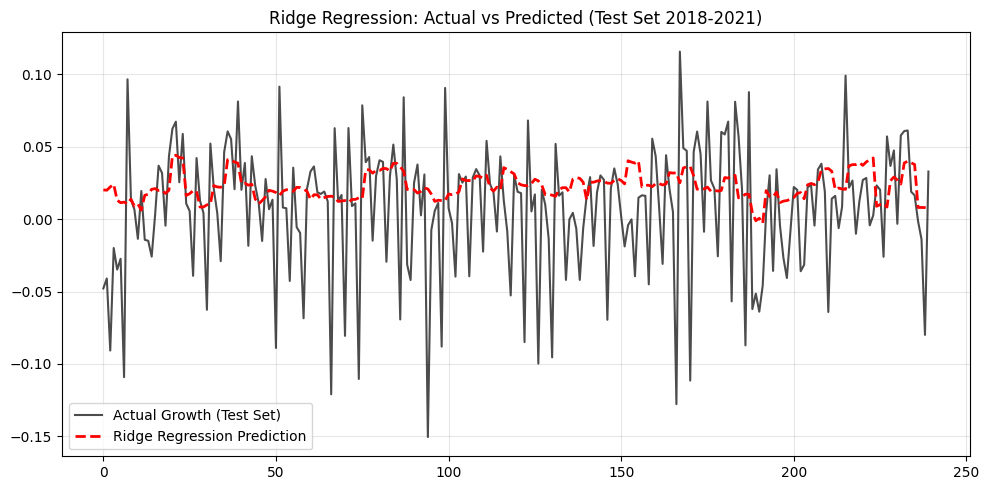


> Model: SVR
Best Parameters: {'C': 0.01, 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': 0.001, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}
RMSE: 0.0463 | MAE: 0.0320 | R²: -0.0774


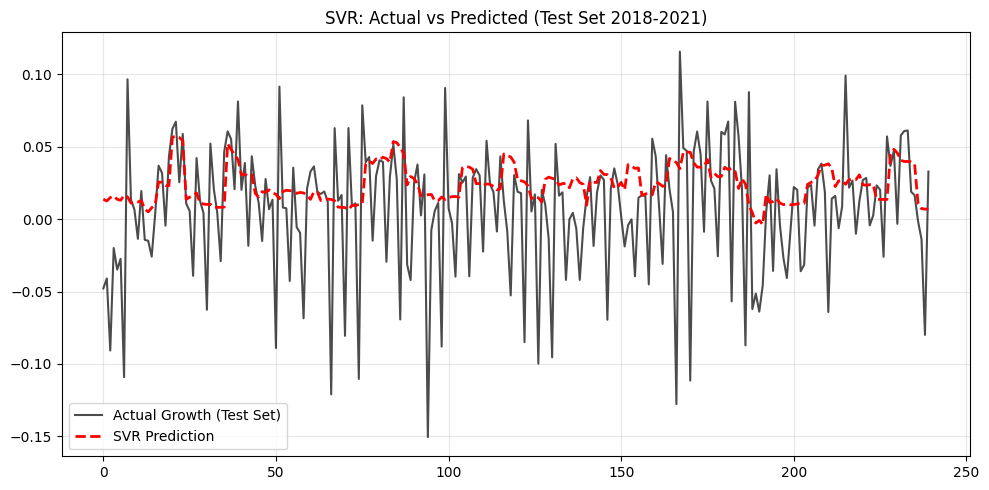


> Model: Random Forest
Best Parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 3, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 15, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 150, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
RMSE: 0.0458 | MAE: 0.0322 | R²: -0.0544


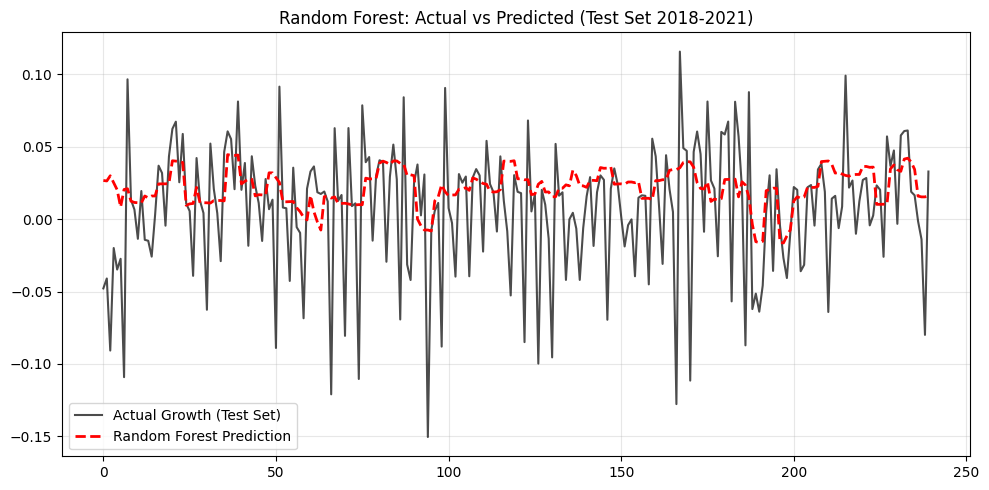


> Model: LSTM
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
RMSE: 0.0453 | MAE: 0.0326 | R²: -0.0287


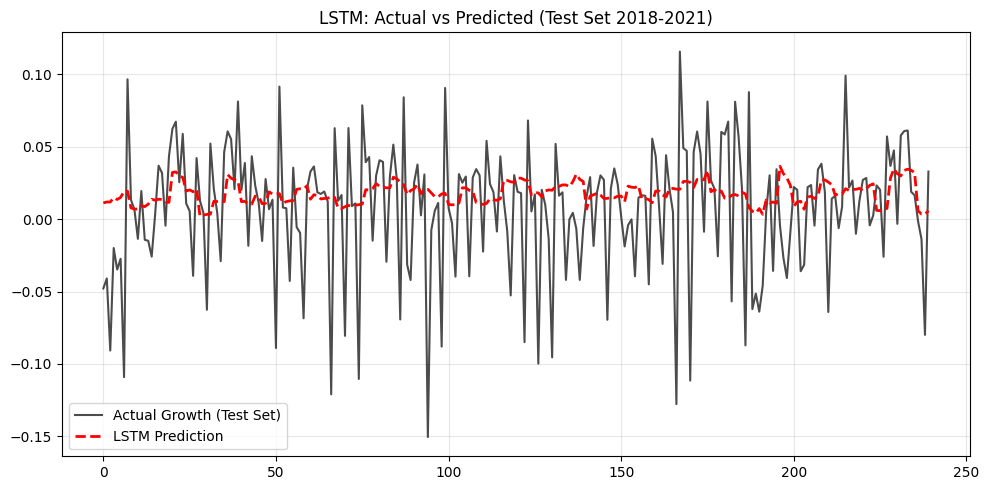


> Model: Hybrid (LSTM + RF)
RMSE: 0.0452 | MAE: 0.0320 | R²: -0.0237


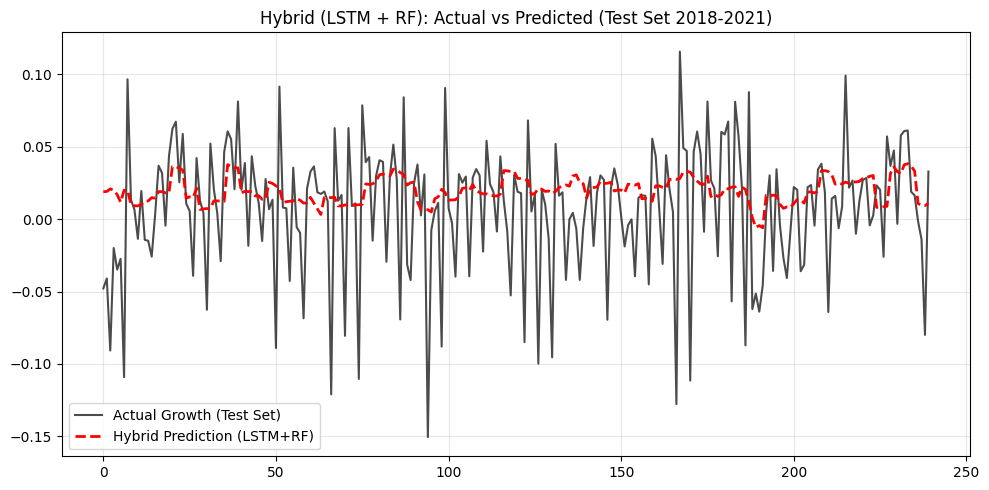


> Model Comparison (Performance on Test Set):
                        RMSE       MAE        R2
Model                                           
Hybrid (LSTM + RF)  0.045153  0.031976 -0.023690
LSTM                0.045262  0.032554 -0.028655
Random Forest       0.045826  0.032244 -0.054434
SVR                 0.046323  0.031994 -0.077433
Ridge Regression    0.046423  0.032833 -0.082094

> Overfitting Analysis Table:
                    Train_RMSE  Test_RMSE  Gap (%)
Model                                             
LSTM                    0.0403     0.0453  12.1999
Hybrid (LSTM + RF)      0.0386     0.0452  16.9996
Ridge Regression        0.0392     0.0464  18.4084
Random Forest           0.0376     0.0458  21.9608
SVR                     0.0374     0.0463  23.9811

BEST MODEL (Lowest RMSE): Hybrid (LSTM + RF) (RMSE: 0.0452)

Step 11 is complete.


In [13]:
# STEP 11: COMPARATIVE MODELLING AND ENSEMBLES

# 11.1 Results and Prediction Storage
results_storage = []
base_predictions_train = {}
base_predictions_test = {}

# 11.2 Helper Function for Sklearn Models (Ridge, RF, SVR)
def train_evaluate_sklearn(model_name, estimator, param_grid, X_tr, y_tr, X_te, y_te):
    '''This function tunes, trains, evaluates, and visualises predictive model.

    Parameters:
    - model_name: Name of the model.  
    - estimator: Sklearn estimator for the model (e.g., RandomForestRegressor).  
    - param_grid: Dictionary of hyperparameters to explore via GridSearchCV.  
    - X_tr, y_tr: Training set. 
    - X_te, y_te: Test set. 

    Process:
    - Performs cross-validation using TimeSeriesSplit to preserve temporal order.  
    - Tunes hyperparameters using GridSearchCV.  
    - Evaluates the model using metrics: RMSE, MAE, R².  
    - Generates and saves a plot comparing actual vs predicted values.  
    - Stores results in a global summary table.

    Returns:
    - best_model: the trained model with the optimal hyperparameters.
    '''
    print(f"\n> Model: {model_name}")
    
    # Use TimeSeriesSplit for cross-validation
    tscv = TimeSeriesSplit(n_splits=3)
    
    # Hyperparameter Tuning
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=0
    )
    
    # Train
    grid_search.fit(X_tr, y_tr)
    best_model = grid_search.best_estimator_
    print(f"Best Parameters: {best_model.get_params()}")
    
    # Predict
    y_pred_test = best_model.predict(X_te)
    y_pred_train = best_model.predict(X_tr)
    
    # Store predictions for ensemble use
    base_predictions_train[model_name] = y_pred_train
    base_predictions_test[model_name] = y_pred_test
    
    # Calculate Metrics
    rmse_train = np.sqrt(mean_squared_error(y_tr, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_te, y_pred_test))
    mae_test = mean_absolute_error(y_te, y_pred_test)
    r2_test = r2_score(y_te, y_pred_test)
    
    print(f"RMSE: {rmse_test:.4f} | MAE: {mae_test:.4f} | R²: {r2_test:.4f}")
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(y_te.values, label='Actual Growth (Test Set)', color='black', alpha=0.7, linewidth=1.5)
    plt.plot(y_pred_test, label=f'{model_name} Prediction', color='red', linestyle='--', linewidth=2)
    plt.title(f'{model_name}: Actual vs Predicted (Test Set 2018-2021)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
        
    filename = f"model_plot_{model_name.replace(' ', '_').lower()}.png"
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
        
    # Store results
    results_storage.append({
        'Model': model_name,
        'RMSE': rmse_test, 'MAE': mae_test, 'R2': r2_test, # For performance table
        'Train_RMSE': rmse_train, 'Test_RMSE': rmse_test # For overfitting table
    })
    
    return best_model

# 11.3 Models
# 1. Ridge Regression (Baseline)
# Anti-Overfitting: 'alpha' (L2 Regularisation)
param_ridge = {'alpha': [1, 10, 100, 200]}
ridge_model = train_evaluate_sklearn('Ridge Regression', Ridge(random_state=SEED_VALUE), param_ridge, X_train_model, y_train, X_test_model, y_test)

# 2. SVR
# Anti-Overfitting: 'C' (Regularisation)
param_svr = {'C': [0.001, 0.01, 0.1, 1], 'kernel': ['rbf', 'linear'], 'epsilon': [0.001, 0.01, 0.1]}
svr_model = train_evaluate_sklearn('SVR', SVR(), param_svr, X_train_model, y_train, X_test_model, y_test)

# 3. Random Forest
# Anti-Overfitting: 'max_depth' & 'min_samples_leaf' (Pruning)
param_rf = {'n_estimators': [100, 150], 'max_depth': [3, 5, 7], 'min_samples_leaf': [5, 10, 15]}
rf_model = train_evaluate_sklearn('Random Forest', RandomForestRegressor(random_state=SEED_VALUE), param_rf, X_train_model, y_train, X_test_model, y_test) 

# 4. LSTM
print(f"\n> Model: LSTM")
X_train_lstm = X_train_model.values.reshape((X_train_model.shape[0], 1, X_train_model.shape[1]))
X_test_lstm = X_test_model.values.reshape((X_test_model.shape[0], 1, X_test_model.shape[1]))

# Create a function for lstm model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(64, activation='relu', return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2)) # Anti-Overfitting
    model.add(LSTM(32, activation='relu'))
    model.add(Dropout(0.2)) # Anti-Overfitting
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

lstm_model = build_lstm_model((X_train_lstm.shape[1], X_train_lstm.shape[2]))
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True) # Anti-Overfitting

history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=100, batch_size=32, validation_split=0.2, 
    callbacks=[early_stop], verbose=0
)

# Predict & Evaluate LSTM
y_pred_test_lstm = lstm_model.predict(X_test_lstm).flatten()
y_pred_train_lstm = lstm_model.predict(X_train_lstm).flatten()

# Store LSTM predictions
base_predictions_train['LSTM'] = y_pred_train_lstm
base_predictions_test['LSTM'] = y_pred_test_lstm

# Calculate LSTM Metrics
rmse_train_lstm = np.sqrt(mean_squared_error(y_train, y_pred_train_lstm))
rmse_test_lstm = np.sqrt(mean_squared_error(y_test, y_pred_test_lstm))
mae_test_lstm = mean_absolute_error(y_test, y_pred_test_lstm)
r2_test_lstm = r2_score(y_test, y_pred_test_lstm)
print(f"RMSE: {rmse_test_lstm:.4f} | MAE: {mae_test_lstm:.4f} | R²: {r2_test_lstm:.4f}")

# Plot LSTM
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual Growth (Test Set)', color='black', alpha=0.7, linewidth=1.5)
plt.plot(y_pred_test_lstm, label='LSTM Prediction', color='red', linestyle='--', linewidth=2)
plt.title('LSTM: Actual vs Predicted (Test Set 2018-2021)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model_plot_lstm.png', dpi=300, bbox_inches='tight')
plt.show()

# Store LSTM results
results_storage.append({
    'Model': 'LSTM',
    'RMSE': rmse_test_lstm, 'MAE': mae_test_lstm, 'R2': r2_test_lstm, # For performance table
    'Train_RMSE': rmse_train_lstm, 'Test_RMSE': rmse_test_lstm # For overfitting table
})

# 5. Ensemble: Hybrid (LSTM + RF)
print(f"\n> Model: Hybrid (LSTM + RF)")
# Manual average of the base models' predictions
y_pred_train_hyb = (base_predictions_train['LSTM'] + base_predictions_train['Random Forest']) / 2.0
y_pred_test_hyb = (base_predictions_test['LSTM'] + base_predictions_test['Random Forest']) / 2.0

# Evaluate
rmse_train_hyb = np.sqrt(mean_squared_error(y_train, y_pred_train_hyb))
rmse_test_hyb = np.sqrt(mean_squared_error(y_test, y_pred_test_hyb))
mae_test_hyb = mean_absolute_error(y_test, y_pred_test_hyb)
r2_test_hyb = r2_score(y_test, y_pred_test_hyb)
print(f"RMSE: {rmse_test_hyb:.4f} | MAE: {mae_test_hyb:.4f} | R²: {r2_test_hyb:.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual Growth (Test Set)', color='black', alpha=0.7, linewidth=1.5)
plt.plot(y_pred_test_hyb, label='Hybrid Prediction (LSTM+RF)', color='red', linestyle='--', linewidth=2)
plt.title('Hybrid (LSTM + RF): Actual vs Predicted (Test Set 2018-2021)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model_plot_hybrid_lstm_rf.png', dpi=300, bbox_inches='tight')
plt.show()

# Store results
results_storage.append({
    'Model': 'Hybrid (LSTM + RF)',
    'RMSE': rmse_test_hyb, 'MAE': mae_test_hyb, 'R2': r2_test_hyb, # For performance table
    'Train_RMSE': rmse_train_hyb, 'Test_RMSE': rmse_test_hyb, # For overfitting table
})

# 11.4 Final Results
# 1. Performance Table
print(f"\n> Model Comparison (Performance on Test Set):")
comparison_df = pd.DataFrame(results_storage).set_index('Model')
comparison_df = comparison_df.sort_values(by='RMSE')
print(comparison_df[['RMSE', 'MAE', 'R2']])

# 2. Overfitting Analysis Table
print(f"\n> Overfitting Analysis Table:")
overfitting_df = comparison_df[['Train_RMSE', 'Test_RMSE']].copy()
overfitting_df['Gap (%)'] = ((overfitting_df['Test_RMSE'] - overfitting_df['Train_RMSE']) / overfitting_df['Train_RMSE']) * 100
overfitting_df = overfitting_df.sort_values(by='Gap (%)')
print(overfitting_df.to_string(float_format="%.4f"))

# 3. Display Winner
winner_model = comparison_df.index[0]
winner_rmse = comparison_df.iloc[0]['RMSE']
print(f"\nBEST MODEL (Lowest RMSE): {winner_model} (RMSE: {winner_rmse:.4f})")

print(f"\nStep 11 is complete.")

#### Step 12: Comparative Driver Analysis (SHAP Heatmap)

This script uses the SHAP library to explain the trained Random Forest model. It calculates the average impact of each of the 20 variables on the model's predictions, allowing to identify and visualise the most important drivers of growth, globally and by income group.

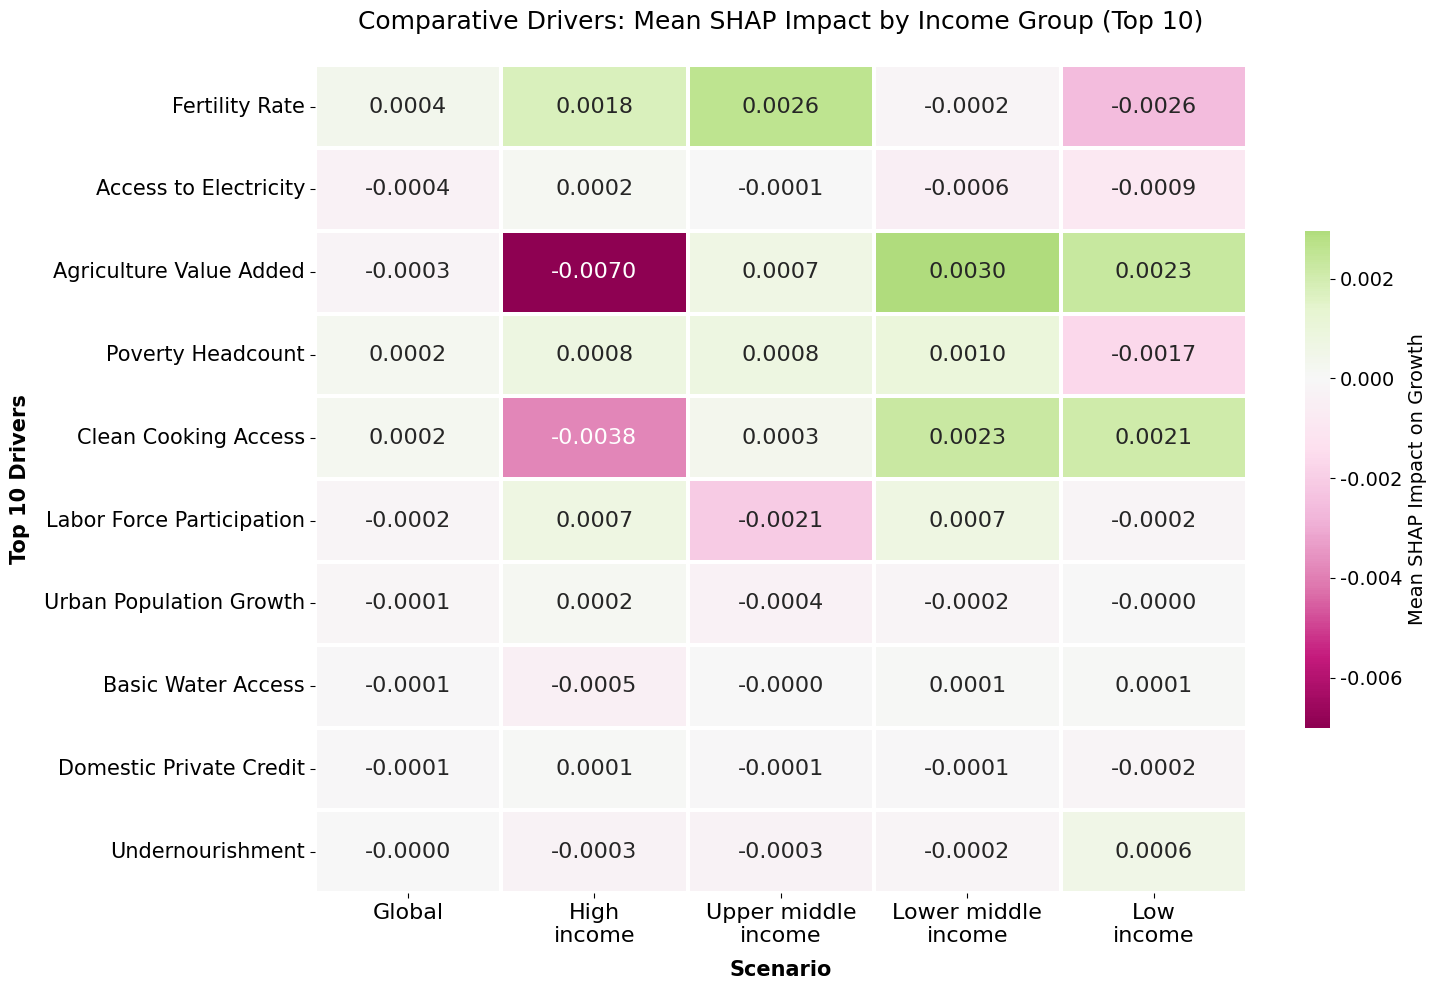

> COMPARATIVE DRIVER DATA (TOP 10):
                                                                         Global  High income  Upper middle income  Lower middle income  Low income
Variable Name                                                                                                                                     
Fertility rate, total (births per woman)                                0.00040      0.00177              0.00260             -0.00019    -0.00259
Access to electricity (% of population)                                -0.00036      0.00018             -0.00008             -0.00060    -0.00093
Agriculture, forestry, and fishing, value added (% of GDP)             -0.00026     -0.00700              0.00067              0.00296     0.00232
Poverty headcount ratio at national poverty lines (% of population)     0.00023      0.00082              0.00079              0.00099    -0.00168
Access to clean fuels and technologies for cooking (% of population)    0.00021   

In [14]:
# STEP 12: COMPARATIVE DRIVER ANALYSIS (SHAP HEATMAP)

# 12.1 Prepare Model and Data
# Use the Random Forest model ('rf_model') from Step 11.
model_to_explain = rf_model 

# Combine Train and Test for full analysis
X_all_scaled = pd.concat([X_train_model, X_test_model], axis=0)

# 12.2 Calculate SHAP Values (Global)
explainer = shap.TreeExplainer(model_to_explain)
shap_values = explainer.shap_values(X_all_scaled)

# Convert to DataFrame
shap_df = pd.DataFrame(shap_values, columns=X_all_scaled.columns, index=X_all_scaled.index)

# B. Calculate Group Mean SHAP
income_groups = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']

# 12.3 Link to Income Groups
# Map Income Group to the SHAP DataFrame
group_map = country_meta.set_index('Country Code')['Income Group'].to_dict()
df_final['Income Group'] = df_final['Country Code'].map(group_map)
shap_df_merged = shap_df.merge(df_final[['Income Group']], left_index=True, right_index=True)

# 12.4 Build Comparison DataFrame
# A. Calculate Global Mean SHAP
global_mean = shap_df.mean()
comparison_df = pd.DataFrame(global_mean, columns=['Global'])

# B. Calculate Group Mean SHAP
income_groups = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']

for group in income_groups:
    # Filter for the group
    group_shap = shap_df_merged[shap_df_merged['Income Group'] == group]
    
    if not group_shap.empty:
        # Calculate mean SHAP for the 20 features
        # Drop the 'Income Group' column to do the math
        group_mean = group_shap.drop(columns=['Income Group']).mean()
        comparison_df[group] = group_mean
    else:
        comparison_df[group] = 0.0

# 12.5 Generate Heatmap
# Filter for Top 10 Global Drivers
comparison_df['Abs_Global'] = comparison_df['Global'].abs()
top_10_df = comparison_df.sort_values(by='Abs_Global', ascending=False).head(10)
heatmap_data = top_10_df.drop(columns=['Abs_Global'])

# Dictionary for Variables for Better Visualisation
clean_labels = {
    'Fertility rate, total (births per woman)': 'Fertility Rate',
    'Access to electricity (% of population)': 'Access to Electricity',
    'Agriculture, forestry, and fishing, value added (% of GDP)': 'Agriculture Value Added',
    'Poverty headcount ratio at national poverty lines (% of population)': 'Poverty Headcount',
    'Access to clean fuels and technologies for cooking (% of population)': 'Clean Cooking Access',
    'Labor force participation rate, total (% of total population ages 15+)': 'Labor Force Participation',
    'Urban population growth (annual %)': 'Urban Population Growth',
    'People using at least basic drinking water services (% of population)': 'Basic Water Access',
    'Domestic credit to private sector (% of GDP)': 'Domestic Private Credit',
    'Prevalence of undernourishment (% of population)': 'Undernourishment',
    'Gross savings (% of GDP)': 'Gross Savings',
    'CO2 emissions (metric tons per capita)': 'CO2 Emissions',
    'Industry (including construction), value added (% of GDP)': 'Industry Value Added',
    'Exports of goods and services (% of GDP)': 'Exports',
    'Imports of goods and services (% of GDP)': 'Imports'
}

# Prepare Data
plot_data = heatmap_data.copy()
plot_data.rename(index=clean_labels, inplace=True)

# Wrap Column Labels (Income groups)
new_columns = []
for col in plot_data.columns:
    if "middle" in col: 
        new_col = col.replace(" income", "\nincome") 
    elif "income" in col:
        new_col = col.replace(" ", "\n")
    else:
        new_col = col
    new_columns.append(new_col)

plot_data.columns = new_columns

# Visualisation
plt.figure(figsize=(15, 10))
ax = sns.heatmap(
    plot_data,
    annot=True,
    fmt=".4f",
    cmap="PiYG",
    center=0,
    linewidths=1.5,
    linecolor='white',
    annot_kws={"size": 16},
    cbar_kws={
        'label': 'Mean SHAP Impact on Growth', 
        'shrink': 0.6,
        'format': '%.3f'
    },
    yticklabels=True
)

# Formatting
plt.title('Comparative Drivers: Mean SHAP Impact by Income Group (Top 10)\n', fontsize=18)
plt.xlabel('Scenario', fontsize=15, weight='bold', labelpad=10)
plt.ylabel('Top 10 Drivers', fontsize=15, weight='bold', labelpad=10)
plt.xticks(rotation=0, fontsize=16, ha='center') 
plt.yticks(rotation=0, fontsize=15) 

# Colorbar Font
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.ax.yaxis.label.set_size(14)

# Adjust, Save and Show
plt.tight_layout()
plt.savefig('comparative_drivers_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print Table
print("> COMPARATIVE DRIVER DATA (TOP 10):")
print(heatmap_data.to_string(float_format="%.5f"))

print(f"\nStep 12 is complete.")

#### Step 13: Distribution Shift Analysis

This script performs a distribution shift analysis using Kernel Density Estimation (KDE) to empirically demonstrate the structural break caused by the COVID-19 pandemic. By overlaying the probability density functions of the historical training regime (2001–2017) against the specific shock period (2020), the visualisation highlights the fundamental divergence in the underlying data generation process. This graphical evidence supports the discussion on 'Dataset Shift', justifying the degradation of model performance during the exogeneous shock.

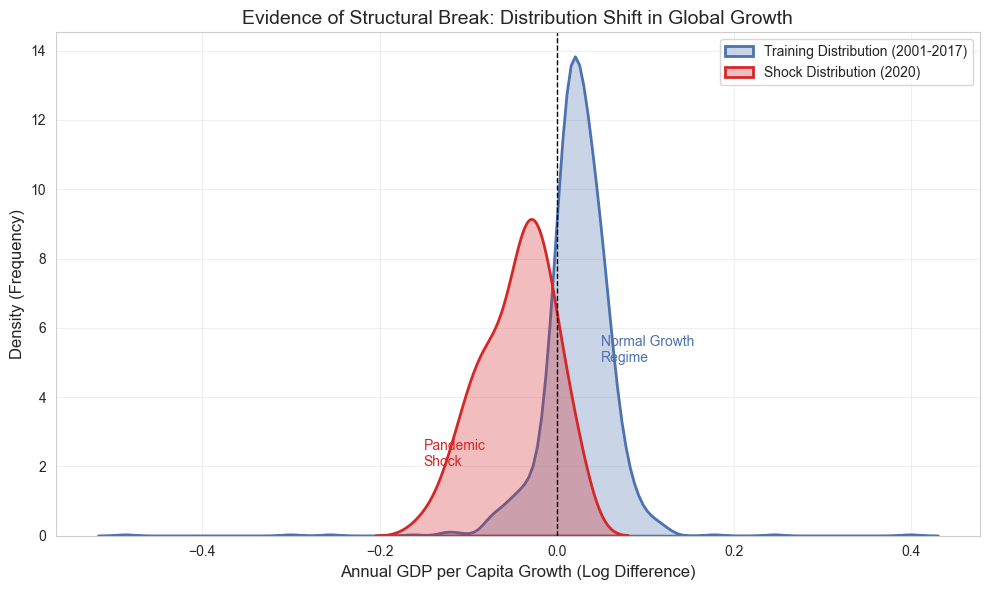


Step 13 is complete.


In [15]:
# STEP 13: DISTRIBUTION SHIFT ANALYSIS (KDE PLOT)

# 13.0 Reset Styles
sns.set_context("notebook", font_scale=1.0) # Reset scaling to normal
plt.style.use('default') # Reset matplotlib defaults
sns.set_style("whitegrid") # Apply a clean grid style

# 13.1 Split Data
# Historical Data
train_dist = df_final[df_final['Year'] <= 2017]['Target_Growth']

# Shock Data (Pandemic Impact)
shock_dist = df_final[df_final['Year'] == 2020]['Target_Growth']

# 13.2 Configure Plot
plt.figure(figsize=(10, 6))

# Plot Training
sns.kdeplot(
    train_dist, 
    color='#4c72b0', 
    fill=True, 
    label='Training Distribution (2001-2017)', 
    linewidth=2,
    alpha=0.3
)

# Plot Shock (2020)
sns.kdeplot(
    shock_dist, 
    color='#d62728', 
    fill=True, 
    label='Shock Distribution (2020)', 
    linewidth=2,
    alpha=0.3
)

# Formatting
plt.title('Evidence of Structural Break: Distribution Shift in Global Growth', fontsize=14)
plt.xlabel('Annual GDP per Capita Growth (Log Difference)', fontsize=12)
plt.ylabel('Density (Frequency)', fontsize=12)
plt.axvline(0, color='black', linestyle='--', linewidth=1) # Zero growth line
plt.grid(True, alpha=0.3)

# Add Annotations and Legend
plt.text(0.05, 5, 'Normal Growth\nRegime', fontsize=10, color='#4c72b0')
plt.text(-0.15, 2, 'Pandemic\nShock', fontsize=10, color='#d62728')
plt.legend()

# Adjust, Save and Show
plt.tight_layout()
plt.savefig('figure_distribution_shift_covid.png', dpi=300)
plt.show()

print(f"\nStep 13 is complete.")